In [166]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.autograd import Variable
import matplotlib.pyplot as plt

In [167]:

#load dataset
data = pd.read_excel(r"../df.xlsx")
df = data.iloc[27:,:] # from 1992-2025
df.head()


print(df.info())

print(df.shape)

df = df.sort_values('Date')

df.set_index('Date', inplace=True)
df.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 67 entries, 27 to 93
Data columns (total 42 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       67 non-null     datetime64[us]
 1   Year                       67 non-null     int64         
 2   Season                     67 non-null     str           
 3   Sown_Extent_Major          67 non-null     int64         
 4   Sown_Extent_Minor          67 non-null     int64         
 5   Sown_Extent_Rainfall       67 non-null     int64         
 6   Sown_Extent_Total          67 non-null     int64         
 7   Harvested_Extent_Major     67 non-null     int64         
 8   Harvested_Extent_Minor     67 non-null     int64         
 9   Harvested_Extent_Rainfall  67 non-null     int64         
 10  Harvested_Extent_Total     67 non-null     int64         
 11  Avg_Yield_Major            67 non-null     int64         
 12  Avg_Yield_Minor     

,Year,Season,Sown_Extent_Major,Sown_Extent_Minor,Sown_Extent_Rainfall,Sown_Extent_Total,Harvested_Extent_Major,Harvested_Extent_Minor,Harvested_Extent_Rainfall,Harvested_Extent_Total,...,Fung_Used,Fung_NotUsed,Short_Grain_Red,Long_Grain_Red,Short_Grain_White,Long_Grain_White,Other(seed_variety),New_Improved,Old_Improved,Traditional
Date,,,,,,,,,,,,,,,,,,,,,
1992-04-01,1992,Yala,130502,49825,74657,254983,122937,47463,72833,243236,...,24.10,75.90,0.0,0.0,0.0,0.0,0.0,90.55,0.81,8.64
1992-09-01,1993,Maha,247069,130475,168145,545689,245058,127580,165398,538060,...,24.32,75.68,0.0,0.0,0.0,0.0,0.0,89.89,1.43,8.68
1993-04-01,1993,Yala,162398,45118,81088,288605,160944,43231,77531,281706,...,18.27,81.73,0.0,0.0,0.0,0.0,0.0,90.25,1.12,8.63


In [168]:
ts = df["Production"]
ts.tail()

Date
2023-04-01    1817.39
2023-09-01    2721.96
2024-04-01    1976.50
2024-09-01    2745.30
2025-04-01    2308.40
Name: Production, dtype: float64

In [169]:
# train / test split
train_size = int(len(ts) * 0.8)

train = ts.iloc[:train_size]
test = ts.iloc[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 53
Test size: 14


In [170]:
train_data = train.values.reshape(-1,1)

In [171]:
print(train_data)

[[ 711.2 ]
 [1695.5 ]
 [ 879.7 ]
 [1673.1 ]
 [1014.7 ]
 [1764.1 ]
 [1050.7 ]
 [1333.6 ]
 [ 731.5 ]
 [1459.6 ]
 [ 783.7 ]
 [1784.2 ]
 [ 912.8 ]
 [1738.8 ]
 [1123.3 ]
 [1781.2 ]
 [1077.6 ]
 [1614.  ]
 [1083.  ]
 [1774.5 ]
 [1089.1 ]
 [1896.8 ]
 [1172.2 ]
 [1669.7 ]
 [ 958.2 ]
 [2012.7 ]
 [1233.5 ]
 [2135.6 ]
 [1206.3 ]
 [1973.1 ]
 [1158.2 ]
 [2126.  ]
 [1750.4 ]
 [2384.  ]
 [1267.7 ]
 [2629.6 ]
 [1671.1 ]
 [1996.2 ]
 [1898.  ]
 [2717.  ]
 [1129.  ]
 [2846.3 ]
 [1774.5 ]
 [2235.9 ]
 [1144.9 ]
 [2877.  ]
 [1942.4 ]
 [2902.69]
 [1517.39]
 [1473.83]
 [ 909.32]
 [2396.93]
 [1532.91]]


In [172]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range= (-1,1))
train_data_normalized = scaler.fit_transform(train_data)

In [173]:
train_data_normalized

array([[-1.        ],
       [-0.10170706],
       [-0.84622335],
       [-0.12214977],
       [-0.7230195 ],
       [-0.03910125],
       [-0.69016514],
       [-0.43198463],
       [-0.98147379],
       [-0.31699437],
       [-0.93383497],
       [-0.02075757],
       [-0.81601559],
       [-0.06219056],
       [-0.62390885],
       [-0.02349543],
       [-0.66561563],
       [-0.17608568],
       [-0.66068748],
       [-0.02960999],
       [-0.65512049],
       [ 0.08200357],
       [-0.57928168],
       [-0.12525268],
       [-0.77458259],
       [ 0.18777635],
       [-0.523338  ],
       [ 0.29993749],
       [-0.5481613 ],
       [ 0.15163656],
       [-0.59205837],
       [ 0.29117632],
       [-0.05160416],
       [ 0.52663257],
       [-0.49212636],
       [ 0.75077231],
       [-0.12397501],
       [ 0.17271811],
       [ 0.08309871],
       [ 0.83053539],
       [-0.61870691],
       [ 0.9485373 ],
       [-0.02960999],
       [ 0.39147338],
       [-0.60419623],
       [ 0

In [174]:
train_data_normalized = torch.FloatTensor(train_data_normalized).view(-1)

In [175]:
type(train_data_normalized)

torch.Tensor

In [176]:
class LSTM(nn.Module):
    def __init__(self, input_size= 1, hidden_layer_size = 100, output_size = 1):
        super().__init__()
        self.hidden_layer_size = hidden_layer_size

        self.lstm = nn.LSTM(input_size, hidden_layer_size)

        self.linear = nn.Linear(hidden_layer_size, output_size)
    
    def forward(self, input_seq):
        lstm_out, _ = self.lstm(input_seq.view(len(input_seq), 1, -1))
        predictions = self.linear(lstm_out.view(len(input_seq), -1))
        return predictions[-1]

In [177]:
model = LSTM()

In [178]:
loss_function = nn.MSELoss()

In [179]:
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [180]:
def create_inout_sequences(input_data, input_seq_len):
    inout_seq = [ ]
    L = len(input_data)
    for i in range(L - input_seq_len):
        train_seq = input_data[i:i + input_seq_len]
        train_label = input_data[i + input_seq_len:i +input_seq_len +1]
        inout_seq.append((train_seq, train_label))

        return inout_seq

In [181]:
epochs = 400

In [182]:
all_losses = [ ]

In [183]:
for epoch in range(epochs):
    for seq , labels in create_inout_sequences(train_data_normalized, input_seq_len=5):
        optimizer.zero_grad()
        y_pred = model(seq)

        single_loss = loss_function(y_pred, labels)
        single_loss.backward()
        optimizer.step()

    all_losses.append(single_loss.item())

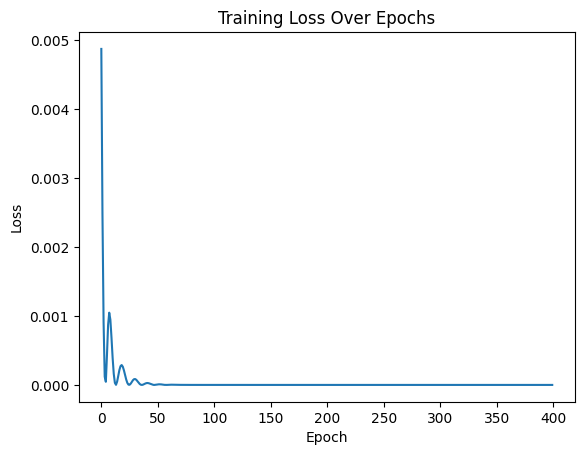

In [184]:
plt.plot(all_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.show()

In [185]:
ts.head()

Date
1992-04-01     711.2
1992-09-01    1695.5
1993-04-01     879.7
1993-09-01    1673.1
1994-04-01    1014.7
Name: Production, dtype: float64

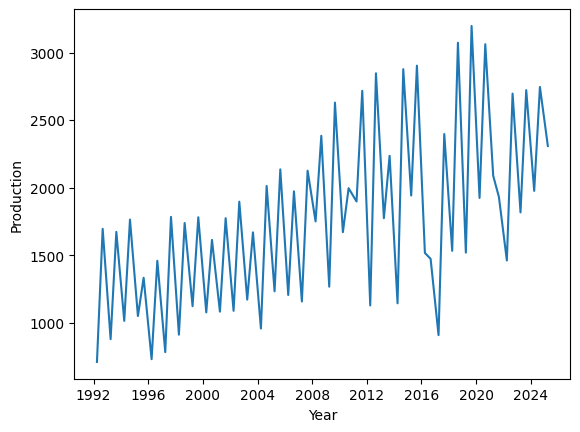

In [186]:
plt.plot(ts.index, ts)
plt.xlabel("Year")
plt.ylabel("Production")
plt.show()

In [187]:
future = len(test)

model.eval()

LSTM(
  (lstm): LSTM(1, 100)
  (linear): Linear(in_features=100, out_features=1, bias=True)
)

In [188]:
for i in range(future):
    with torch.no_grad():
        seq = train_data_normalized[-5:]
        for _ in range(future):
            y_pred = model(seq)
            seq = torch.cat((seq, y_pred.view(-1)))

In [189]:
predicted_values = scaler.inverse_transform(np.array(seq).reshape(-1,1))
# predicted_values = pd.Series(scaler.inverse_transform(np.array(seq).reshape(-1,1)))
predicted_values = pd.Series(predicted_values)
predicted_values

C:\Users\User\AppData\Local\Temp\ipykernel_13492\504043787.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  predicted_values = scaler.inverse_transform(np.array(seq).reshape(-1,1))


ValueError: Data must be 1-dimensional, got ndarray of shape (19, 1) instead

ValueError: x and y must have same first dimension, but have shapes (14,) and (19, 1)

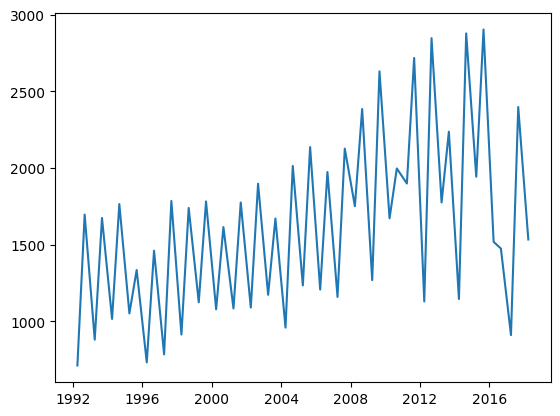

In [ ]:
plt.plot(train.index , train.values , label = "Train")
plt.plot(test.index , predicted_values, label = "Predictions")
plt.plot(test.index, test, label='Actual')
plt.xlabel("Date")
plt.ylabel("Linear Values")
plt.title("LSTM Model Predictions")
plt.legend()
plt.show()
# predicted_values[-future:]

In [ ]:
# plt.plot(train.index, train, labels ="Train")
# plt.plot(test.index, test, label='Actual')
# plt.plot(pd)
